In [1]:
from astropy.table import Table
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from scipy.optimize import least_squares

df = pd.read_csv("M41_query_result_full.csv")

df.head()

,random_index,source_id,ra,dec,parallax,parallax_over_error,pmdec,pmdec_error,pmra,pmra_error,ruwe,phot_g_mean_mag,phot_bp_mean_mag,phot_rp_mean_mag,bp_rp
0,1381651595,2926059827481255680,101.871514,-21.638468,0.708287,15.724628,-4.061186,0.041292,-0.045740,0.029029,1.055384,16.628632,17.203814,15.902876,1.300938
1,226379506,2926062576260337408,101.791043,-21.639748,0.856612,6.924300,-2.894021,0.112050,1.558011,0.080318,0.975567,18.450891,19.332483,17.522280,1.810204
2,741620331,2926062610615673472,101.767416,-21.651002,2.363314,1.571006,11.480609,1.119343,9.070124,0.716237,1.118750,20.810562,21.877844,19.674230,2.203613
3,1021135133,2926062919857705472,101.840912,-21.604856,1.955211,113.311530,-35.483904,0.015670,-11.917450,0.011108,1.002468,14.496161,14.930145,13.892927,1.037218
4,340816657,2926061614178561024,101.706995,-21.683744,0.868512,2.326162,2.742589,0.346593,2.426535,0.208912,1.020591,19.892107,20.634743,18.969057,1.665686


In [2]:
cols_needed = [
    "source_id",
    "ra",
    "dec",
    "parallax",
    "pmra",
    "pmdec",
    "pmra_error",
    "pmdec_error",
    "phot_g_mean_mag",
    "bp_rp"
]

for c in cols_needed:
    print(c, c in df.columns)

source_id True
ra True
dec True
parallax True
pmra True
pmdec True
pmra_error True
pmdec_error True
phot_g_mean_mag True
bp_rp True


In [3]:
df = df.replace([np.inf, -np.inf], np.nan)

df_clean = df.dropna(subset=[
    "pmra", "pmdec",
    "phot_g_mean_mag", "bp_rp"
]).copy()

print("Número de estrellas:", len(df_clean))

Número de estrellas: 27590


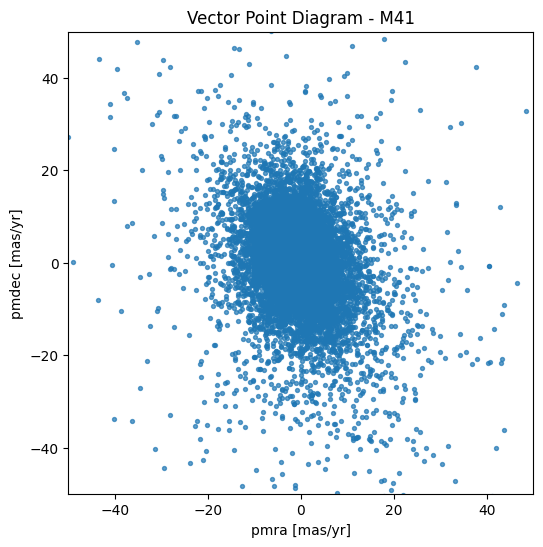

In [4]:
plt.figure(figsize=(6,6))
plt.scatter(df_clean["pmra"], df_clean["pmdec"], s=8, alpha=0.7)
plt.xlabel("pmra [mas/yr]")
plt.ylabel("pmdec [mas/yr]")
plt.title("Vector Point Diagram - M41")
plt.xlim(-50, 50)
plt.ylim(-50, 50)
plt.show()

In [5]:
mux = df["pmra"].values
muy = df["pmdec"].values

In [6]:
def psi_cluster(mux, muy, muxc, muyc, sigma):
    norm = 1.0 / (2.0 * np.pi * sigma**2)
    expo = -0.5 * (((mux - muxc)**2 + (muy - muyc)**2) / sigma**2)
    return norm * np.exp(expo)

def psi_field(mux, muy, muxf, muyf, sigx, sigy, rho):
    norm = 1.0 / (2.0 * np.pi * sigx * sigy * np.sqrt(1.0 - rho**2))
    X = (mux - muxf) / sigx
    Y = (muy - muyf) / sigy
    Omega = X**2 + Y**2 - 2.0 * rho * X * Y
    expo = -Omega / (2.0 * (1.0 - rho**2))
    return norm * np.exp(expo)

def psi_total(params, mux, muy):
    muxf, muyf, sigx, sigy, muxc, muyc, sigma, nf, rho = params

    pc = psi_cluster(mux, muy, muxc, muyc, sigma)
    pf = psi_field(mux, muy, muxf, muyf, sigx, sigy, rho)

    return (1.0 - nf) * pc + nf * pf

In [7]:
def log_likelihood(params, mux, muy):
    psi = psi_total(params, mux, muy)
    if np.any(psi <= 0):
        return -np.inf
    return np.sum(np.log(psi))

In [8]:
def score_equations(params, mux, muy, eps=1e-6):
    grad = np.zeros(len(params))
    base = log_likelihood(params, mux, muy)

    for i in range(len(params)):
        p1 = params.copy()
        p2 = params.copy()

        step = eps * max(1.0, abs(params[i]))
        p1[i] += step
        p2[i] -= step

        f1 = log_likelihood(p1, mux, muy)
        f2 = log_likelihood(p2, mux, muy)

        if not np.isfinite(f1) or not np.isfinite(f2):
            grad[i] = 1e10
        else:
            grad[i] = (f1 - f2) / (2.0 * step)

    return grad

In [9]:
theta0 = np.array([
    -2.0,   # muxf
    -0.5,   # muyf
    1.5,    # sigx
    1.0,    # sigy
    -4.6,   # muxc
    -1.4,   # muyc
    0.3,    # sigma
    0.7,    # nf
    0.0     # rho
], dtype=float)

theta0

array([-2. , -0.5,  1.5,  1. , -4.6, -1.4,  0.3,  0.7,  0. ])

In [10]:
result = least_squares(
    score_equations,
    theta0,
    args=(mux, muy),
    method="lm"
)

result

     message: `gtol` termination condition is satisfied.
     success: True
      status: 1
         fun: [ 1.000e+10  1.000e+10  1.000e+10  1.000e+10  1.000e+10
                1.000e+10  1.000e+10  1.000e+10  1.000e+10]
           x: [-2.000e+00 -5.000e-01  1.500e+00  1.000e+00 -4.600e+00
               -1.400e+00  3.000e-01  7.000e-01  0.000e+00]
        cost: 4.5e+20
         jac: [[-0.000e+00 -0.000e+00 ...  0.000e+00  0.000e+00]
               [-0.000e+00 -0.000e+00 ...  0.000e+00  0.000e+00]
               ...
               [-0.000e+00 -0.000e+00 ...  0.000e+00  0.000e+00]
               [-0.000e+00 -0.000e+00 ...  0.000e+00  0.000e+00]]
        grad: [ 0.000e+00  0.000e+00  0.000e+00  0.000e+00  0.000e+00
                0.000e+00  0.000e+00  0.000e+00  0.000e+00]
  optimality: 0.0
 active_mask: [0 0 0 0 0 0 0 0 0]
        nfev: 1
        njev: None

In [11]:
theta_hat = result.x

param_names = [
    "muxf", "muyf", "sigx", "sigy",
    "muxc", "muyc", "sigma", "nf", "rho"
]

for name, val in zip(param_names, theta_hat):
    print(f"{name:6s} = {val:.6f}")

muxf   = -2.000000
muyf   = -0.500000
sigx   = 1.500000
sigy   = 1.000000
muxc   = -4.600000
muyc   = -1.400000
sigma  = 0.300000
nf     = 0.700000
rho    = 0.000000


In [12]:
muxf, muyf, sigx, sigy, muxc, muyc, sigma, nf, rho = theta_hat

pc = psi_cluster(mux, muy, muxc, muyc, sigma)
pf = psi_field(mux, muy, muxf, muyf, sigx, sigy, rho)

P_member = ((1.0 - nf) * pc) / (((1.0 - nf) * pc) + (nf * pf))

df["P_member"] = P_member
df["is_member"] = df["P_member"] > 0.5

print("Miembros con P > 0.5:", df["is_member"].sum())

Miembros con P > 0.5: 1281


/tmp/ipykernel_302/3316503927.py:6: RuntimeWarning: invalid value encountered in divide
  P_member = ((1.0 - nf) * pc) / (((1.0 - nf) * pc) + (nf * pf))


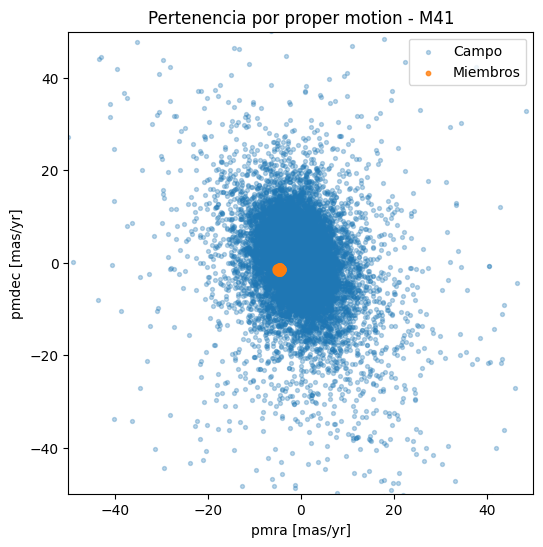

In [13]:
plt.figure(figsize=(6,6))

plt.scatter(
    df.loc[~df["is_member"], "pmra"],
    df.loc[~df["is_member"], "pmdec"],
    s=8, alpha=0.3, label="Campo"
)

plt.scatter(
    df.loc[df["is_member"], "pmra"],
    df.loc[df["is_member"], "pmdec"],
    s=10, alpha=0.8, label="Miembros"
)

plt.xlabel("pmra [mas/yr]")
plt.ylabel("pmdec [mas/yr]")
plt.title("Pertenencia por proper motion - M41")
plt.legend()
plt.xlim(-50, 50)
plt.ylim(-50, 50)
plt.show()

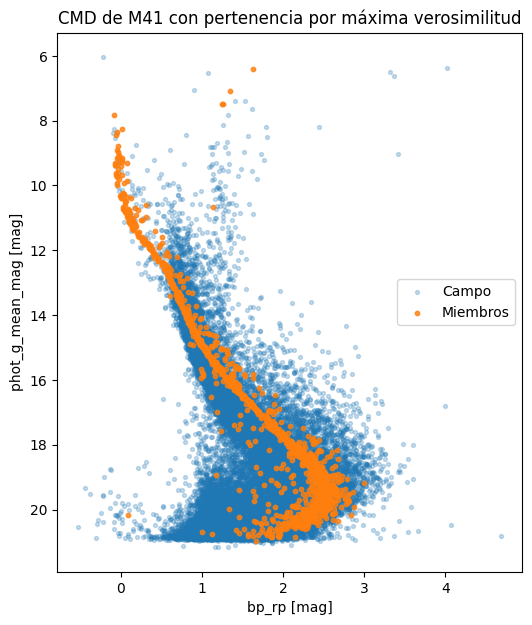

In [14]:
plt.figure(figsize=(6,7))

plt.scatter(
    df.loc[~df["is_member"], "bp_rp"],
    df.loc[~df["is_member"], "phot_g_mean_mag"],
    s=8, alpha=0.25, label="Campo"
)

plt.scatter(
    df.loc[df["is_member"], "bp_rp"],
    df.loc[df["is_member"], "phot_g_mean_mag"],
    s=10, alpha=0.8, label="Miembros"
)

plt.gca().invert_yaxis()
plt.xlabel("bp_rp [mag]")
plt.ylabel("phot_g_mean_mag [mag]")
plt.title("CMD de M41 con pertenencia por máxima verosimilitud")
plt.legend()
plt.show()

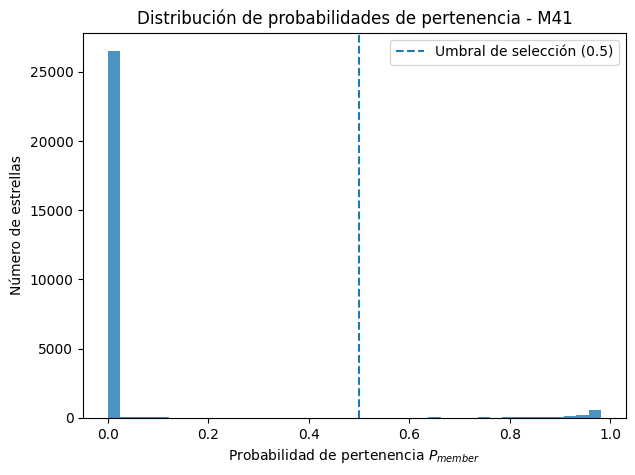

In [15]:
plt.figure(figsize=(7,5))

plt.hist(df["P_member"], bins=40, alpha=0.8)

plt.xlabel("Probabilidad de pertenencia $P_{member}$")
plt.ylabel("Número de estrellas")
plt.title("Distribución de probabilidades de pertenencia - M41")

plt.axvline(0.5, linestyle="--", label="Umbral de selección (0.5)")
plt.legend()

plt.show()